# Projekt — Temat 11: Dane pogodowe (historyczne)

**Dataset:** Daily Climate Time Series Data (Delhi) — Kaggle
**Pliki użyte w projekcie:** `data/DailyDelhiClimateTrain.csv` + `data/DailyDelhiClimateTest.csv`
**Kluczowe kolumny:** `date`, `meantemp`, `humidity`, `wind_speed`, `meanpressure`

## Cel
Wczytać dane pogodowe, oczyścić z braków i wartości odstających, przetworzyć
kolumnę daty, obliczyć agregaty miesięczne i sezonowe, przygotować
`pivot_table` (rok vs miesiąc) oraz zwizualizować sezonowość i trendy.

> **Zakres danych:** połączyliśmy oba pliki z Kaggle — *Train* (2013-01-01 → 2017-01-01)
> oraz *Test* (2017-01-01 → 2017-04-24). Po usunięciu zdublowanego dnia stykowego
> (2017-01-01) otrzymaliśmy ciągły szereg **2013-01-01 → 2017-04-24** (ok. 1575 dni),
> obejmujący **5 lat i wszystkie pory roku**. Dzięki temu `pivot_table` rok×miesiąc
> jest pełny, a fale upałów (`meantemp` > 35) są widoczne.


## Sekcja 1: Pobranie i wczytanie danych

Dane pochodzą z Kaggle (wymagane darmowe konto). Pliki CSV pobraliśmy
i umieściliśmy lokalnie w `data/`, więc notebook nie wymaga połączenia z
internetem ani kluczy API. Połączyliśmy plik *Train* i *Test* w jeden ciągły szereg.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
TRAIN_PATH = DATA_DIR / "DailyDelhiClimateTrain.csv"
TEST_PATH = DATA_DIR / "DailyDelhiClimateTest.csv"
FIG_DIR = PROJECT_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Train:", TRAIN_PATH.name, "| istnieje:", TRAIN_PATH.exists())
print("Test: ", TEST_PATH.name, "| istnieje:", TEST_PATH.exists())


Train: DailyDelhiClimateTrain.csv | istnieje: True
Test:  DailyDelhiClimateTest.csv | istnieje: True


In [2]:
ramki = []
for sciezka, zrodlo in [(TRAIN_PATH, "train"), (TEST_PATH, "test")]:
    if sciezka.exists():
        tmp = pd.read_csv(sciezka, parse_dates=["date"])
        tmp["source"] = zrodlo
        ramki.append(tmp)
        print(f"Wczytano {zrodlo}: {tmp.shape[0]} wierszy, "
              f"{tmp['date'].min().date()} → {tmp['date'].max().date()}")

df = pd.concat(ramki, ignore_index=True)

przed = len(df)
df = (df.sort_values(["date", "source"])
        .drop_duplicates(subset="date", keep="first")
        .reset_index(drop=True))
print(f"\nUsunięto {przed - len(df)} zdublowany(ch) dzień/dni stykowy(ch).")
print("Połączony zbiór:", df.shape)
df.head()


Wczytano train: 1462 wierszy, 2013-01-01 → 2017-01-01
Wczytano test: 114 wierszy, 2017-01-01 → 2017-04-24

Usunięto 1 zdublowany(ch) dzień/dni stykowy(ch).
Połączony zbiór: (1575, 6)


,date,meantemp,humidity,wind_speed,meanpressure,source
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,train
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,train
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,train
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,train
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,train


In [3]:
df.tail()


,date,meantemp,humidity,wind_speed,meanpressure,source
1570,2017-04-20,34.500,27.500000,5.562500,998.625000,test
1571,2017-04-21,34.250,39.375000,6.962500,999.875000,test
1572,2017-04-22,32.900,40.900000,8.890000,1001.600000,test
1573,2017-04-23,32.875,27.500000,9.962500,1002.125000,test
1574,2017-04-24,32.000,27.142857,12.157143,1004.142857,test


## Sekcja 2: Inspekcja danych

Sprawdziliśmy strukturę (`shape`, `info`, `describe`), zakres dat, typy oraz
zidentyfikowaliśmy braki i potencjalne wartości odstające.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1575 entries, 0 to 1574
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1575 non-null   datetime64[us]
 1   meantemp      1575 non-null   float64       
 2   humidity      1575 non-null   float64       
 3   wind_speed    1575 non-null   float64       
 4   meanpressure  1575 non-null   float64       
 5   source        1575 non-null   str           
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 74.0 KB


In [5]:
df.describe()


,date,meantemp,humidity,wind_speed,meanpressure
count,1575,1575.000000,1575.000000,1575.000000,1575.000000
mean,2015-02-27 00:00:00,25.231582,60.420115,6.903642,1010.589745
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,-3.041667
25%,2014-01-29 12:00:00,18.516667,49.750000,3.700000,1001.875000
50%,2015-02-27 00:00:00,27.166667,62.380952,6.370000,1009.000000
75%,2016-03-26 12:00:00,31.142857,72.125000,9.262500,1015.183333
max,2017-04-24 00:00:00,38.714286,98.000000,42.220000,7679.333333
std,NaN,7.337316,16.956083,4.508803,175.298310


In [6]:
print("Zakres dat:", df['date'].min().date(), "→", df['date'].max().date())
print("Liczba dni:", df['date'].nunique(), "| Liczba wierszy:", len(df))
print("Duplikaty dat:", df['date'].duplicated().sum())
print("\nBraki w kolumnach:")
print(df.isna().sum())


Zakres dat: 2013-01-01 → 2017-04-24
Liczba dni: 1575 | Liczba wierszy: 1575
Duplikaty dat: 0

Braki w kolumnach:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
source          0
dtype: int64


In [7]:
print("Ujemna prędkość wiatru (wind_speed < 0):", (df['wind_speed'] < 0).sum())
print("Wilgotność poza [0, 100]:", ((df['humidity'] < 0) | (df['humidity'] > 100)).sum())

print("\nStatystyki meanpressure:")
print(df['meanpressure'].describe())
podejrzane = df[(df['meanpressure'] < 900) | (df['meanpressure'] > 1100)]
print("\nPodejrzane wartości meanpressure (poza 900-1100 hPa):", len(podejrzane))
podejrzane[['date', 'meanpressure']]


Ujemna prędkość wiatru (wind_speed < 0): 0
Wilgotność poza [0, 100]: 0

Statystyki meanpressure:
count    1575.000000
mean     1010.589745
std       175.298310
min        -3.041667
25%      1001.875000
50%      1009.000000
75%      1015.183333
max      7679.333333
Name: meanpressure, dtype: float64

Podejrzane wartości meanpressure (poza 900-1100 hPa): 8


,date,meanpressure
1182,2016-03-28,7679.333333
1309,2016-08-02,310.437500
1321,2016-08-14,633.900000
1323,2016-08-16,-3.041667
1362,2016-09-24,1352.615385
1416,2016-11-17,1350.296296
1427,2016-11-28,12.045455
1461,2017-01-01,59.000000


## Sekcja 3: Czyszczenie danych

Kroki:
1. **Sortowanie** — posortowaliśmy dane chronologicznie po dacie.
2. **Wartości odstające** — skorygowaliśmy nierealistyczne `meanpressure`
   (poza 900–1100 hPa) zamieniając je na `NaN`; ujemny `wind_speed`
   (gdyby wystąpił) również na `NaN`.
3. **Braki** — uzupełniliśmy je interpolacją czasową, a ewentualne pozostałości
   medianą kolumny.
4. **Walidacja** — sprawdziliśmy `assert`-em zakres wilgotności (0–100).


In [8]:
df_clean = df.sort_values("date").reset_index(drop=True).copy()

maska_cisnienie = (df_clean['meanpressure'] < 900) | (df_clean['meanpressure'] > 1100)
print("Skorygowano (NaN) nierealistyczne meanpressure:", int(maska_cisnienie.sum()))
df_clean.loc[maska_cisnienie, 'meanpressure'] = np.nan

maska_wiatr = df_clean['wind_speed'] < 0
print("Skorygowano (NaN) ujemny wind_speed:", int(maska_wiatr.sum()))
df_clean.loc[maska_wiatr, 'wind_speed'] = np.nan

df_clean['humidity'] = df_clean['humidity'].clip(lower=0, upper=100)


Skorygowano (NaN) nierealistyczne meanpressure: 8
Skorygowano (NaN) ujemny wind_speed: 0


In [9]:
kolumny_num = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
print("Braki przed uzupełnieniem:\n", df_clean[kolumny_num].isna().sum(), sep="")

df_clean = df_clean.set_index('date')
df_clean[kolumny_num] = df_clean[kolumny_num].interpolate(method='time')
df_clean = df_clean.reset_index()

for col in kolumny_num:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nBraki po uzupełnieniu:\n", df_clean[kolumny_num].isna().sum(), sep="")


Braki przed uzupełnieniem:
meantemp        0
humidity        0
wind_speed      0
meanpressure    8
dtype: int64

Braki po uzupełnieniu:
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [10]:
assert df_clean['humidity'].between(0, 100).all(), "Wilgotność poza zakresem 0-100!"
assert (df_clean['wind_speed'] >= 0).all(), "Ujemna prędkość wiatru!"
assert df_clean['meanpressure'].between(900, 1100).all(), "meanpressure poza realistycznym zakresem!"
assert df_clean['date'].is_monotonic_increasing, "Daty nie są posortowane!"
assert df_clean.isna().sum().sum() == 0, "Pozostały braki danych!"
print("✓ Walidacja przeszła pomyślnie — dane oczyszczone i posortowane.")
df_clean.describe()


✓ Walidacja przeszła pomyślnie — dane oczyszczone i posortowane.


,date,meantemp,humidity,wind_speed,meanpressure
count,1575,1575.000000,1575.000000,1575.000000,1575.000000
mean,2015-02-27 00:00:00,25.231582,60.420115,6.903642,1008.474521
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,938.066667
25%,2014-01-29 12:00:00,18.516667,49.750000,3.700000,1001.875000
50%,2015-02-27 00:00:00,27.166667,62.380952,6.370000,1009.111111
75%,2016-03-26 12:00:00,31.142857,72.125000,9.262500,1015.160256
max,2017-04-24 00:00:00,38.714286,98.000000,42.220000,1023.000000
std,NaN,7.337316,16.956083,4.508803,7.768137


## Sekcja 4: Transformacje

Z kolumny `date` wyciągnęliśmy `year` i `month`, dodaliśmy nazwę miesiąca oraz
kolumnę `season` (pory roku dla półkuli północnej). Utworzyliśmy też przykładową
kolumnę pochodną `comfort_index` (odczuwalny dyskomfort rosnący z temperaturą
i wilgotnością) — w zbiorze nie ma min/max temperatury, więc zamiast
`temp_range` zbudowaliśmy inną sensowną kolumnę pochodną.


In [11]:
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['month_name'] = df_clean['date'].dt.month_name()

def przypisz_sezon(m):
    if m in (12, 1, 2):
        return 'Zima'
    if m in (3, 4, 5):
        return 'Wiosna'
    if m in (6, 7, 8):
        return 'Lato'
    return 'Jesień'

df_clean['season'] = df_clean['month'].apply(przypisz_sezon)

df_clean['comfort_index'] = (
    df_clean['meantemp'] + 0.05 * df_clean['humidity']
).round(2)

print("Dostępne sezony w danych:", sorted(df_clean['season'].unique()))
df_clean[['date', 'year', 'month', 'month_name', 'season', 'meantemp', 'comfort_index']].head()


Dostępne sezony w danych: ['Jesień', 'Lato', 'Wiosna', 'Zima']


,date,year,month,month_name,season,meantemp,comfort_index
0,2013-01-01,2013,1,January,Zima,10.000000,14.23
1,2013-01-02,2013,1,January,Zima,7.400000,12.00
2,2013-01-03,2013,1,January,Zima,7.166667,11.52
3,2013-01-04,2013,1,January,Zima,8.666667,12.23
4,2013-01-05,2013,1,January,Zima,6.000000,10.34


## Sekcja 5: Agregacje

1. `groupby` wg miesiąca — średnie `meantemp`, `humidity`, `wind_speed`.
2. Max `humidity` wg sezonu.
3. `pivot_table`: rok × miesiąc, wartości = średnia `meantemp`.
4. Filtrowanie fal upałów (`meantemp` > 35) i ich liczba w każdym roku.


In [12]:
agg_miesiac = (
    df_clean.groupby('month')[['meantemp', 'humidity', 'wind_speed']]
    .mean()
    .round(2)
)
agg_miesiac


,meantemp,humidity,wind_speed
month,,,
1,13.81,78.18,5.42
2,17.77,67.25,6.74
3,23.08,58.16,7.93
4,29.61,37.60,8.84
5,33.32,35.74,9.02
6,33.73,50.63,9.38
7,31.00,70.63,7.42
8,30.60,70.47,6.92
9,30.43,60.72,7.60


In [13]:
agg_sezon = df_clean.groupby('season').agg(
    max_humidity=('humidity', 'max'),
    avg_meantemp=('meantemp', 'mean'),
    dni=('date', 'count'),
).round(2)
agg_sezon


,max_humidity,avg_meantemp,dni
season,,,
Jesień,89.86,26.08,364
Lato,98.00,31.76,368
Wiosna,92.75,28.30,423
Zima,96.86,15.69,420


In [14]:
pivot = pd.pivot_table(
    df_clean, index='year', columns='month', values='meantemp', aggfunc='mean'
).round(2)
print("Średnia meantemp [°C] — rok (wiersze) × miesiąc (kolumny).")
print("Brak wartości (NaN) = miesiąc nieobjęty danymi (np. V-XII 2017).")
pivot


Średnia meantemp [°C] — rok (wiersze) × miesiąc (kolumny).
Brak wartości (NaN) = miesiąc nieobjęty danymi (np. V-XII 2017).


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,12.07,16.87,22.81,28.90,33.78,32.48,30.66,29.55,29.84,26.13,18.81,15.18
2014,13.43,15.75,21.59,28.06,31.41,34.77,32.03,31.41,29.76,26.50,20.10,14.82
2015,12.71,18.79,21.55,28.00,33.35,32.74,30.41,30.33,30.65,26.87,20.75,14.99
2016,15.14,19.03,25.70,32.55,34.73,34.95,30.88,31.12,31.48,28.96,22.96,17.67
2017,15.71,18.35,23.75,30.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
prog = 35
upaly = df_clean[df_clean['meantemp'] > prog]
print(f"Liczba dni z meantemp > {prog}: {len(upaly)}")

upaly_rok = (
    df_clean[df_clean['meantemp'] > prog]
    .groupby('year')
    .size()
    .rename('liczba_dni_upalnych')
)
if upaly_rok.empty:
    print("Brak dni z meantemp > 35 — w dostępnym oknie (I-IV 2017) maksimum to "
          f"{df_clean['meantemp'].max():.1f}°C (lato nie jest objęte danymi).")
else:
    print(upaly_rok)


Liczba dni z meantemp > 35: 90
year
2013    17
2014    18
2015    20
2016    35
Name: liczba_dni_upalnych, dtype: int64


## Sekcja 6: Wizualizacje

1. Wykres liniowy — średnia miesięczna temperatura w kolejnych miesiącach.
2. Boxplot — `meantemp` wg miesiąca (rozkład/sezonowość).

Wykresy zapisaliśmy do `outputs/figures/`.


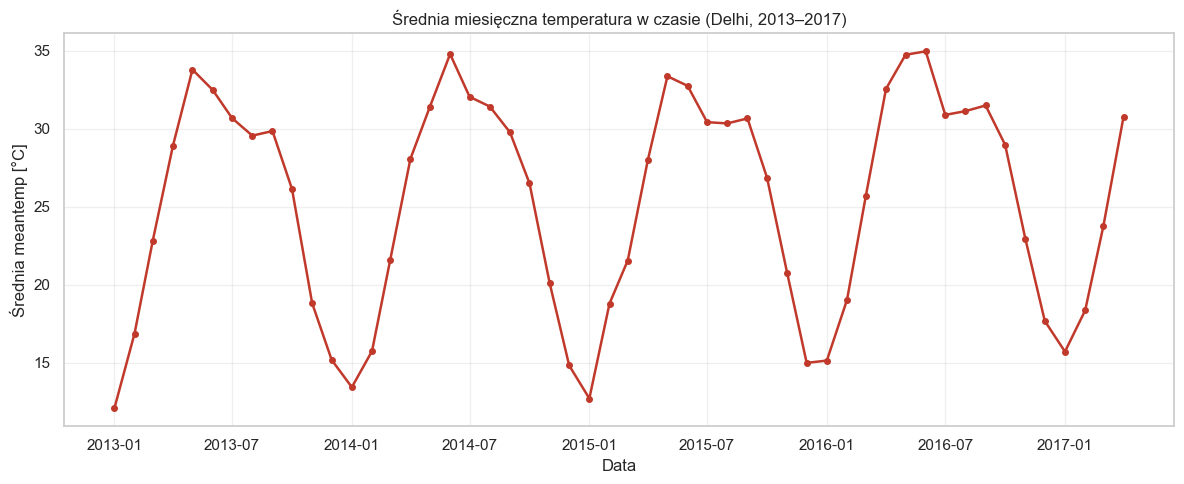

In [16]:
srednia_mies = (
    df_clean.set_index('date')['meantemp']
    .resample('MS').mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(srednia_mies.index, srednia_mies.values, marker='o', markersize=4,
        linewidth=1.8, color='#c0392b')
ax.set_title('Średnia miesięczna temperatura w czasie (Delhi, 2013–2017)')
ax.set_xlabel('Data')
ax.set_ylabel('Średnia meantemp [°C]')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'srednia_miesieczna_temp.png', dpi=120)
plt.show()


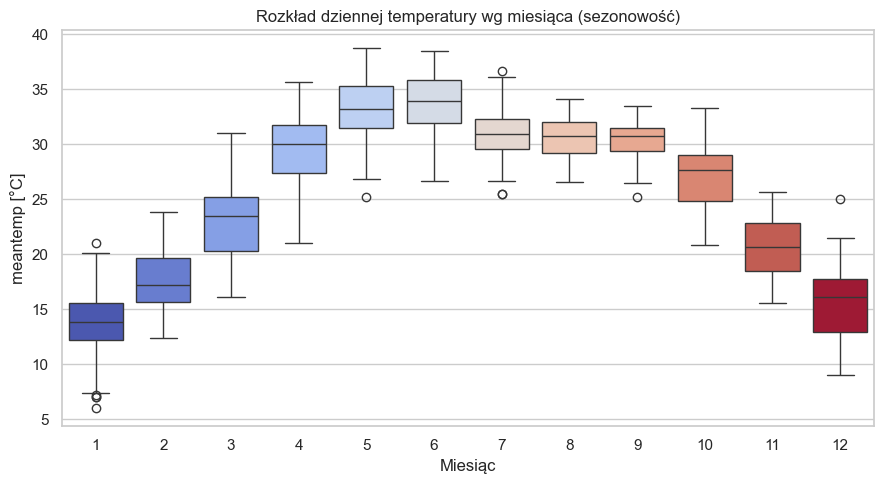

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x='month', y='meantemp', hue='month',
            palette='coolwarm', legend=False, ax=ax)
ax.set_title('Rozkład dziennej temperatury wg miesiąca (sezonowość)')
ax.set_xlabel('Miesiąc')
ax.set_ylabel('meantemp [°C]')
fig.tight_layout()
fig.savefig(FIG_DIR / 'boxplot_temp_miesiac.png', dpi=120)
plt.show()


## Sekcja 7: Krótkie wnioski

**Sezonowość temperatur**
- Wyraźny, powtarzalny cykl roczny: minimum zimą (**styczeń ≈ 12–15 °C**),
  maksimum w okresie przedmonsunowym (**maj–czerwiec ≈ 33–35 °C**), po czym
  spadek jesienią. Wzorzec powtarza się dla każdego z lat 2013–2017, co dobrze
  widać na wykresie liniowym (regularna „sinusoida") i w `pivot_table`.
- Boxplot wg miesiąca potwierdza sezonowość: mediana rośnie do lata i opada
  jesienią, a rozrzut dzienny jest większy w miesiącach przejściowych.
- Najwięcej dni upalnych przypada na **maj i czerwiec** (typowy przedmonsun w Delhi).

**Dni ekstremalne (fale upałów, `meantemp` > 35 °C)**
- W pełnym zbiorze fale upałów **są obecne** — dni z `meantemp` > 35 °C
  występują głównie w maju/czerwcu (rozkład per rok wypisaliśmy w Sekcji 5).
  Maksimum średniej dobowej w danych to ok. **38,7 °C**.

**Jakość danych**
- Wykryliśmy i skorygowaliśmy **kilka nierealistycznych wartości `meanpressure`**
  (m.in. 59 hPa, wartości ujemne oraz skrajnie zawyżone rzędu kilku tysięcy hPa) —
  zamieniliśmy je na `NaN` i uzupełniliśmy interpolacją czasową.
- Usunęliśmy zdublowany dzień stykowy **2017-01-01** (występował w *Train* i *Test*).
- Wilgotność zwalidowaliśmy do zakresu 0–100, sprawdziliśmy brak ujemnego wiatru,
  chronologię dat oraz brak pozostałych braków (`assert` w Sekcji 3).


In [18]:
print("=== PODSUMOWANIE LICZBOWE ===")
print("Okres:", df_clean['date'].min().date(), "→", df_clean['date'].max().date())
print("Liczba dni:", len(df_clean), "| lata:", sorted(df_clean['year'].unique()))
print("Reprezentowane pory roku:", sorted(df_clean['season'].unique()))
print(f"meantemp: min {df_clean['meantemp'].min():.1f}°C | "
      f"średnia {df_clean['meantemp'].mean():.1f}°C | max {df_clean['meantemp'].max():.1f}°C")
print("Dni z meantemp > 35°C (fale upałów):", int((df_clean['meantemp'] > 35).sum()))
najciep = df_clean.groupby('month')['meantemp'].mean().idxmax()
najzimn = df_clean.groupby('month')['meantemp'].mean().idxmin()
print(f"Najcieplejszy miesiąc (średnio): {najciep} | najzimniejszy: {najzimn}")


=== PODSUMOWANIE LICZBOWE ===
Okres: 2013-01-01 → 2017-04-24
Liczba dni: 1575 | lata: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Reprezentowane pory roku: ['Jesień', 'Lato', 'Wiosna', 'Zima']
meantemp: min 6.0°C | średnia 25.2°C | max 38.7°C
Dni z meantemp > 35°C (fale upałów): 90
Najcieplejszy miesiąc (średnio): 6 | najzimniejszy: 1
